#### Creating a random dataset

In [5]:
import pandas as pd, numpy as np

np.random.seed(42)
n = 1000
df = pd.DataFrame({
    "customer_id": range(1001, 1001+n),
    "usage_gb": np.random.gamma(5, 2, n).round(2),          # positively skewed usage
    "call_mins": np.random.normal(350, 120, n).clip(50,900).round(0),
    "complaints": np.random.poisson(0.6, n),
    "plan_type": np.random.choice(["Prepaid","Postpaid"], n, p=[0.6,0.4]),
    "region": np.random.choice(["Delhi","Mumbai","Chennai","Kolkata"], n)
})
# create a realistic bill tied to usage, calls, plan, plus noise
base = 99 + 8*df["usage_gb"] + 0.2*df["call_mins"] + 30*df["complaints"]
base += np.where(df["plan_type"]=="Postpaid", 120, 0)
df["monthly_bill"] = (base + np.random.normal(0, 40, n)).round(2)

df.to_csv("billing_churn.csv", index=False)
print("Saved billing_churn.csv with shape:", df.shape)
df.head()

Saved billing_churn.csv with shape: (1000, 7)


,customer_id,usage_gb,call_mins,complaints,plan_type,region,monthly_bill
0,1001,11.65,543.0,2,Prepaid,Delhi,382.79
1,1002,8.75,508.0,0,Prepaid,Mumbai,342.66
2,1003,8.36,547.0,2,Postpaid,Kolkata,403.22
3,1004,8.36,439.0,1,Prepaid,Delhi,209.56
4,1005,17.95,359.0,2,Prepaid,Kolkata,369.40


#### Load and quick inspect

In [6]:
import pandas as pd
df = pd.read_csv("billing_churn.csv")
print(df.shape); df.head()

(1000, 7)


,customer_id,usage_gb,call_mins,complaints,plan_type,region,monthly_bill
0,1001,11.65,543.0,2,Prepaid,Delhi,382.79
1,1002,8.75,508.0,0,Prepaid,Mumbai,342.66
2,1003,8.36,547.0,2,Postpaid,Kolkata,403.22
3,1004,8.36,439.0,1,Prepaid,Delhi,209.56
4,1005,17.95,359.0,2,Prepaid,Kolkata,369.40


#### Basic preprocessing

In [7]:
import numpy as np

num_features = ["usage_gb","call_mins","complaints"]
X_num = df[num_features].copy()

# Targets
y_reg = df["monthly_bill"]               # regression target

#y_clf = (df["churn"]=="Yes").astype(int) # classification target: Yes->1, No->0

#### Train/test split (same split for both tasks)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X_num, y_reg, test_size=0.3, random_state=42)

#### Model A : Linear Regression (predict monthly_bill)

=== REGRESSION ===
Features: ['usage_gb', 'call_mins', 'complaints']
Coefficients: {'usage_gb': np.float64(8.04), 'call_mins': np.float64(0.224), 'complaints': np.float64(31.985)}
Intercept: 135.42
RMSE: 70.1


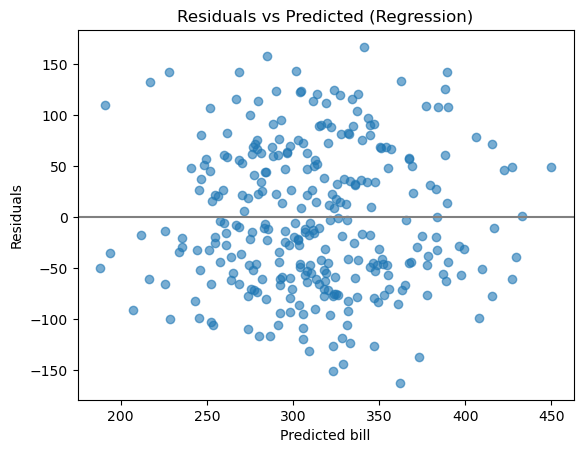


✅ Saved new file with predictions → billing_churn_with_predictions.csv
Preview:
   customer_id  usage_gb  call_mins  complaints plan_type   region  \
0         1001     11.65      543.0           2   Prepaid    Delhi   
1         1002      8.75      508.0           0   Prepaid   Mumbai   
2         1003      8.36      547.0           2  Postpaid  Kolkata   
3         1004      8.36      439.0           1   Prepaid    Delhi   
4         1005     17.95      359.0           2   Prepaid  Kolkata   

   monthly_bill  predicted_monthly_bill  
0        382.79                  414.75  
1        342.66                  319.62  
2        403.22                  389.19  
3        209.56                  333.00  
4        369.40                  424.17  


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

reg = LinearRegression().fit(X_train, y_reg_train)
y_reg_pred = reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))

print("=== REGRESSION ===")
print("Features:", num_features)
print("Coefficients:", dict(zip(num_features, reg.coef_.round(3)))) # how of each of the parameter increase will impact the billing.
print("Intercept:", round(reg.intercept_, 2))
print("RMSE:", round(rmse, 2))

import matplotlib.pyplot as plt
resid = y_reg_test - y_reg_pred
plt.scatter(y_reg_pred, resid, alpha=0.6)
plt.axhline(0, color='gray')
plt.xlabel("Predicted bill"); plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Regression)")
plt.show()

df = pd.read_csv("billing_churn.csv")

X_all = df[num_features]
df["predicted_monthly_bill"] = reg.predict(X_all).round(2)
output_path = "billing_churn_with_predictions.csv"
df.to_csv(output_path, index=False)

print(f"\n✅ Saved new file with predictions → {output_path}")
print("Preview:")
print(df.head())